In [5]:
import os

DATASET_PATH = r"C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData"

files = []
labels = []

for root, _, fs in os.walk(DATASET_PATH):
    for f in fs:
        if f.endswith(".wav"):
            files.append(os.path.join(root, f))
            labels.append(os.path.basename(root))

print("Total files:", len(files))
print("Sample:", files[0])


Total files: 6705
Sample: C:\Users\shaik\OneDrive\Desktop\insturment.ai\archive\IRMAS-TrainingData\cel\008__[cel][nod][cla]0058__1.wav


In [2]:
import pandas as pd

df = pd.DataFrame({
    "file": files,
    "label": labels
})

print(df.head())


                                                file label
0  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
1  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
2  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
3  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel
4  C:\Users\shaik\OneDrive\Desktop\insturment.ai\...   cel


In [6]:
from sklearn.model_selection import train_test_split

train_files, test_files, train_labels, test_labels = train_test_split(
    files,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

print("Train samples:", len(train_files))
print("Test samples:", len(test_files))


Train samples: 5364
Test samples: 1341


In [6]:
import librosa
import numpy as np

SR = 22050

def preprocess_audio(file_path):
    try:
        y, sr = librosa.load(file_path, sr=SR, mono=False)

        # stereo → mono merge
        if y.ndim == 2:
            y = np.mean(y, axis=0)

        # trim silence
        y, _ = librosa.effects.trim(y, top_db=30)

        # skip silence clips
        if len(y) < SR:
            return None

        # normalize
        y = librosa.util.normalize(y)

        return y

    except Exception as e:
        print("Error:", file_path)
        return None


In [7]:
sample_audio = train_files[0]

y = preprocess_audio(sample_audio)

if y is None:
    print("Skipped silent file")
else:
    print("Loaded OK")
    print("Duration:", len(y)/SR, "sec")
    print("Mono:", y.ndim == 1)


Loaded OK
Duration: 3.0 sec
Mono: True


In [8]:
import librosa
import numpy as np

def make_mel_log(y, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


In [9]:
import matplotlib.pyplot as plt
import librosa.display

def save_mel_image(mel_db, save_path):
    plt.figure(figsize=(6,4))

    librosa.display.specshow(
        mel_db,
        sr=SR,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")
    plt.title("Mel Log Spectrogram")
    plt.tight_layout()

    plt.savefig(save_path)
    plt.show()
    plt.close()


Matplotlib is building the font cache; this may take a moment.


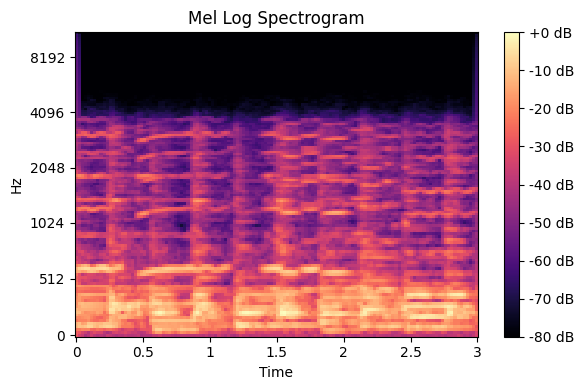

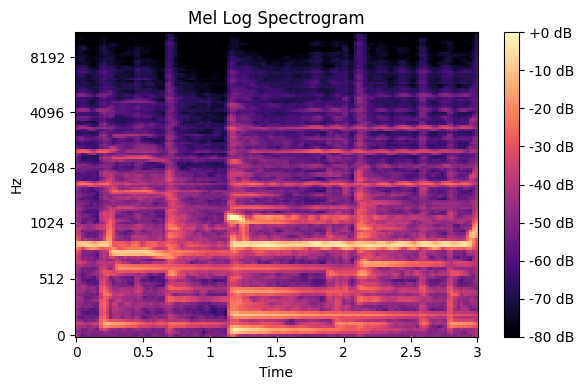

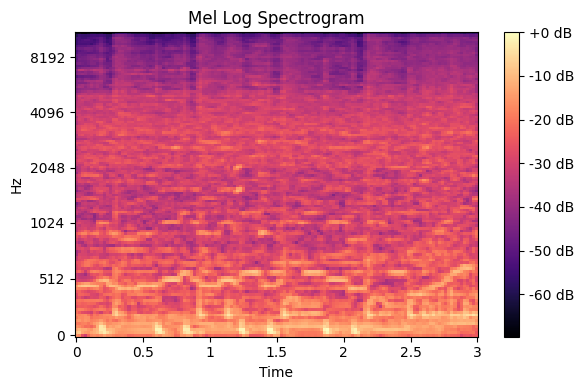

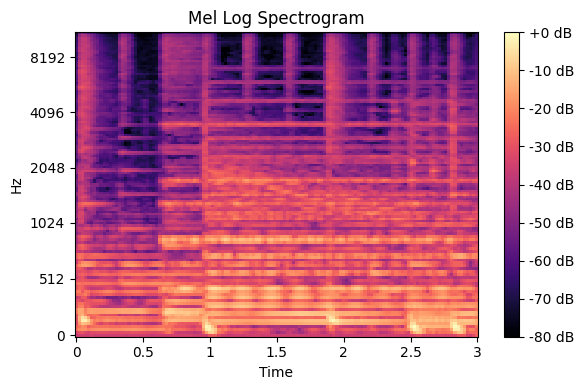

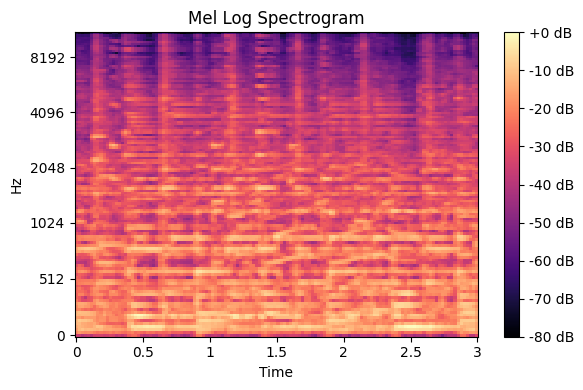

In [11]:
import os
os.makedirs("mel_images", exist_ok=True)

count = 0

for f in train_files:
    y = preprocess_audio(f)
    if y is None:
        continue

    mel_db = make_mel_log(y)
    save_mel_image(mel_db, f"mel_images/mel_{count}.png")

    count += 1
    if count == 5:
        break


In [7]:
unique_labels = sorted(set(labels))
print("Unique instrument classes:")
print(unique_labels)
print("Total classes:", len(unique_labels))

Unique instrument classes:
['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
Total classes: 11


In [8]:
print("Total files:", len(files))
print("Total labels:", len(labels))

Total files: 6705
Total labels: 6705


In [9]:
binary_train_files = []
binary_train_labels = []

binary_test_files = []
binary_test_labels = []

for f, lab in zip(train_files, train_labels):
    if lab in ["pia", "dru"]:
        binary_train_files.append(f)
        binary_train_labels.append(lab)

for f, lab in zip(test_files, test_labels):
    if lab in ["pia", "dru"]:
        binary_test_files.append(f)
        binary_test_labels.append(lab)

print("Train (Piano+Drums):", len(binary_train_files))
print("Test (Piano+Drums):", len(binary_test_files))

Train (Piano+Drums): 577
Test (Piano+Drums): 144


In [10]:
def plot_waveform(y, label):
    plt.figure(figsize=(8,3))
    librosa.display.waveshow(y, sr=SR)
    plt.title(f"Waveform - {label}")
    plt.show()

In [ ]:
for i in range(5):
    file_path = binary_test_files[i]
    true_label = binary_test_labels[i]

    print("\nTest Sample:", i+1)
    print("True Label:", true_label)

    y = preprocess_audio()
    if y is None:
        print("Skipped silent file")
        continue

    # Waveform
    plot_waveform(y, true_label)

    # Mel Spectrogram
    mel_db = make_mel_log(y)
    save_mel_image(mel_db, f"mel_images/test_{i}_{true_label}.png")


Test Sample: 1
True Label: pia


NameError: name 'preprocess_audio' is not defined